# LSTM Bubble Early-Warning Pipeline

Final notebook for the LSTM-based early warning model in our cryptocurrency bubble project.

## Objective
Predict the next-period bubble state using engineered market, sentiment, and macro features.

## Scope
- **Main target:** `gsadf_map_95_lead`
- **Classes:** Not Bubble, Bubble Creation, Bubble Collapse
- **Coins:** ADA, BNB, BTC, DOGE, ETH, SOL

## Notes
- The main benchmark keeps the full 3-class results for all coins.
- **ADA** and **DOGE** are excluded only from the collapse-focused benchmark view because their out-of-sample collapse labels are too sparse under chronological evaluation.
- `gsadf_map_90_lead` is included as an optional robustness rerun for sparse-collapse cases.


## 1. Imports

In [1]:

import os
import random
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130


## 2. Configuration

This section defines:
- dataset paths,
- target labels,
- coins used in the experiment,
- feature set,
- split settings,
- class weights, thresholds, and lookback candidates.


In [2]:

# Paths
DATA_CANDIDATES = [
    "df_features_with_label_standardised.csv",
    "data/df_features_with_label_standardised.csv",
    "/mnt/data/df_features_with_label_standardised.csv",
]

OUTPUT_DIR = Path("lstm_outputs_benchmark_refined")
OUTPUT_DIR.mkdir(exist_ok=True)

# Experiment setup
TARGET_COL = "gsadf_map_95_lead"          # main benchmark label
ROBUSTNESS_TARGET_COL = "gsadf_map_90_lead"   # optional rerun for sparse-collapse coins

CLASS_NAMES = ["Not Bubble", "Bubble Creation", "Bubble Collapse"]
LABELS = [0, 1, 2]

COINS_TO_RUN = ["ADA", "BNB", "BTC", "DOGE", "ETH", "SOL"]
COLLAPSE_BENCHMARK_EXCLUDE = ["ADA", "DOGE"]
COLLAPSE_BENCHMARK_COINS = [c for c in COINS_TO_RUN if c not in COLLAPSE_BENCHMARK_EXCLUDE]
SPARSE_COLLAPSE_ROBUSTNESS_COINS = ["ADA", "DOGE", "ETH"]

# Feature selection
FEATURE_MODE = "manual"

MANUAL_FEATURES = [
    # 1) Price / regime anchor
    "close",
    "ma_30",
    "ma_60",
    "ma_ratio_7_30",
    "ma_ratio_30_60",
    "zscore_30",
    "zscore_60",
    "price_position_60",

    # 2) Momentum / build-up
    "ret_7d",
    "ret_14d",
    "ret_30d",
    "rsi_14",
    "rsi_30",
    "roc_14",
    "roc_30",

    # 3) Volatility / stress
    "atr_14",
    "atr_30",
    "realized_vol_30",
    "volume_ratio_7",
    "volume_std_30",
    "price_volume_corr_30",

    # 4) Search / attention
    "own_trend_ma_14",
    "own_trend_ma_30",
    "own_trend_std_30",
    "crypto_crash_zscore",
    "altcoin_season_zscore",

    # 5) Sentiment level + reversal
    "fear_greed",
    "fear_greed_ma_14",
    "fear_greed_ma_30",
    "fear_greed_change_1d",
    "fear_greed_change_7d",
    "fear_greed_lag_7",
    "extreme_greed",
    "fear",
    "greed",

    # 6) Macro risk regime
    "vix",
    "vix_change_1d",
    "real_rate_10y",
    "risk_off_signal",

    # 7) Short lagged reversal
    "ret_7d_lag_1",
    "rsi_14_lag_1",
    "ret_1d_lag_3",
    "ret_7d_lag_3",
]

LOOKBACK_CANDIDATES_BY_COIN = {
    "ADA": [14, 21],
    "BNB": [14, 21, 30],
    "BTC": [14, 21, 30],
    "DOGE": [14, 21],
    "ETH": [14, 21, 30],
    "SOL": [7, 14, 21],
}
DEFAULT_LOOKBACK_CANDIDATES = [14, 21, 30]

# Manual splits chosen after checking yearly/monthly collapse timing
MANUAL_SPLITS_BY_TARGET = {
    "gsadf_map_95_lead": {
        "ADA":  {"val_start": "2021-06-01", "test_start": "2021-10-01"},
        "BNB":  {"val_start": "2021-03-01", "test_start": "2022-01-01"},
        "BTC":  {"val_start": "2021-03-01", "test_start": "2022-01-01"},
        "DOGE": {"val_start": "2021-06-01", "test_start": "2021-09-01"},
        "ETH":  {"val_start": "2021-06-01", "test_start": "2022-01-01"},
        "SOL":  {"val_start": "2021-10-01", "test_start": "2022-06-01"},
    },
    "gsadf_map_90_lead": {
        "ADA":  {"val_start": "2021-06-01", "test_start": "2021-10-01"},
        "BNB":  {"val_start": "2021-03-01", "test_start": "2022-01-01"},
        "BTC":  {"val_start": "2021-03-01", "test_start": "2022-01-01"},
        "DOGE": {"val_start": "2021-06-01", "test_start": "2021-09-01"},
        "ETH":  {"val_start": "2021-06-01", "test_start": "2022-01-01"},
        "SOL":  {"val_start": "2021-10-01", "test_start": "2022-06-01"},
    },
}

# Training defaults
BATCH_SIZE = 32
EPOCHS = 15
PATIENCE = 4
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-4

HIDDEN_SIZE = 32
NUM_LAYERS = 1
DROPOUT = 0.30
DENSE_SIZE = 16

# Coin-specific class weights
USE_CLASS_WEIGHTS = True
CLASS_WEIGHT_MODE = "manual"

MANUAL_CLASS_WEIGHT_BY_COIN = {
    "ADA":  {0: 1.0, 1: 1.0, 2: 6.0},
    "BNB":  {0: 1.0, 1: 1.2, 2: 6.8},
    "BTC":  {0: 1.0, 1: 1.2, 2: 6.6},
    "DOGE": {0: 1.0, 1: 1.0, 2: 6.0},
    "ETH":  {0: 1.0, 1: 1.3, 2: 6.8},
    "SOL":  {0: 1.0, 1: 1.3, 2: 6.6},
}
DEFAULT_MANUAL_CLASS_WEIGHT = {0: 1.0, 1: 1.2, 2: 1.6}

# Selection / early stopping
COLLAPSE_CLASS = 2
MIN_CLASS_COUNT_WARNING = 5
NO_COLLAPSE_VAL_PENALTY = 0.05
EVENT_SELECTION_WEIGHT_CREATION = 0.55
EVENT_SELECTION_WEIGHT_COLLAPSE = 0.45

# Collapse-aware post-processing / sampling
USE_COLLAPSE_THRESHOLD = True
COLLAPSE_THRESHOLD_GRID_BY_COIN = {
    "BTC": [0.15, 0.20, 0.25, 0.30, 0.35, 0.40],
    "BNB": [0.15, 0.20, 0.25, 0.30, 0.35, 0.40],
    "ETH": [0.10, 0.15, 0.20, 0.25, 0.30, 0.35],
    "SOL": [0.10, 0.15, 0.20, 0.25, 0.30],
    "ADA": [0.20, 0.25, 0.30, 0.35],
    "DOGE": [0.20, 0.25, 0.30, 0.35],
}
DEFAULT_COLLAPSE_THRESHOLD_GRID = [0.15, 0.20, 0.25, 0.30, 0.35]
DEFAULT_FIXED_COLLAPSE_THRESHOLD = 0.25

USE_COLLAPSE_OVERSAMPLING = True
COLLAPSE_OVERSAMPLE_BY_COIN = {
    "BTC": 4,
    "BNB": 5,
    "ETH": 4,
    "SOL": 3,
    "ADA": 1,
    "DOGE": 1,
}
DEFAULT_COLLAPSE_OVERSAMPLE = 1

# Infrastructure
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print("Main target:", TARGET_COL)
print("Collapse benchmark coins:", COLLAPSE_BENCHMARK_COINS)


Using device: cpu
Main target: gsadf_map_95_lead
Collapse benchmark coins: ['BNB', 'BTC', 'ETH', 'SOL']


## 3. Utility Functions

Helper functions for:
- reproducibility,
- file resolution,
- directory creation.


In [3]:

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)


def resolve_data_path(candidates):
    for p in candidates:
        if Path(p).exists():
            return Path(p)
    raise FileNotFoundError(
        "Could not find dataset. Checked:\n" + "\n".join(candidates)
    )


def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)


## 4. Load Data

Load the engineered feature dataset and inspect the basic class distribution for the main target.


In [4]:
data_path = resolve_data_path(DATA_CANDIDATES)

df = pd.read_csv(data_path, parse_dates=["date"])
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

print(f"Loaded: {data_path}")
print(f"Shape : {df.shape}")
print(f"Date range: {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Coins: {sorted(df['symbol'].unique().tolist())}")

print(f"\nClass distribution (target = {TARGET_COL}):")
display(df.groupby("symbol")[TARGET_COL].value_counts().unstack(fill_value=0))

Loaded: df_features_with_label_standardised.csv
Shape : (13359, 146)
Date range: 2018-05-01 -> 2024-12-31
Coins: ['ADA', 'BNB', 'BTC', 'DOGE', 'ETH', 'SOL']

Class distribution (target = gsadf_map_95_lead):


gsadf_map_95_lead,0,1,2
symbol,,,
ADA,2070,265,102
BNB,2075,263,99
BTC,2160,222,55
DOGE,1761,186,60
ETH,2082,288,67
SOL,1344,213,47


## 5. Label Timing Check

Review label timing by coin to support:
- chronological split design,
- interpretation of sparse collapse cases,
- optional robustness testing.


In [5]:

def label_distribution_by_year(df_in: pd.DataFrame, target_col: str):
    out = df_in[["symbol", "date", target_col]].copy()
    out["year"] = out["date"].dt.year
    return (
        out.groupby(["symbol", "year"])[target_col]
        .value_counts()
        .unstack(fill_value=0)
        .rename(columns={0: "not_bubble", 1: "creation", 2: "collapse"})
        .reset_index()
    )

yearly_label_df = label_distribution_by_year(df, TARGET_COL)
display(yearly_label_df)

print("Target used for the main benchmark:", TARGET_COL)
print("Coins excluded from collapse benchmark:", COLLAPSE_BENCHMARK_EXCLUDE)


gsadf_map_95_lead,symbol,year,not_bubble,creation,collapse
0,ADA,2018,245,0,0
1,ADA,2019,365,0,0
2,ADA,2020,339,27,0
3,ADA,2021,77,187,101
4,ADA,2022,364,0,1
5,ADA,2023,337,28,0
6,ADA,2024,343,23,0
7,BNB,2018,245,0,0
8,BNB,2019,352,0,13
9,BNB,2020,364,2,0


Target used for the main benchmark: gsadf_map_95_lead
Coins excluded from collapse benchmark: ['ADA', 'DOGE']


## 6. Feature Setup

Select the final numeric feature set used for sequence modelling.


In [6]:

NON_FEATURE_COLS = [
    "date",
    "symbol",
    "gsadf_map_95",
    "gsadf_map_90",
    "gsadf_map_95_lead",
    "gsadf_map_90_lead",
]

def get_feature_columns(df: pd.DataFrame, feature_mode: str = "all", manual_features=None):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in NON_FEATURE_COLS]

    if feature_mode == "all":
        feature_cols = numeric_cols
    elif feature_mode == "manual":
        if not manual_features:
            raise ValueError("FEATURE_MODE='manual' but MANUAL_FEATURES is empty.")
        missing = [c for c in manual_features if c not in df.columns]
        if missing:
            print("Warning: these manual features were not found and will be skipped:")
            print(missing)
        feature_cols = [c for c in manual_features if c in numeric_cols]
    else:
        raise ValueError("feature_mode must be 'all' or 'manual'")

    if len(feature_cols) == 0:
        raise ValueError("No usable feature columns selected.")

    return feature_cols

FEATURE_COLS = get_feature_columns(df, feature_mode=FEATURE_MODE, manual_features=MANUAL_FEATURES)
print(f"Feature mode: {FEATURE_MODE}")
print(f"Number of features: {len(FEATURE_COLS)}")
print(FEATURE_COLS[:20], "..." if len(FEATURE_COLS) > 20 else "")


['risk_off_signal']
Feature mode: manual
Number of features: 42
['close', 'ma_30', 'ma_60', 'ma_ratio_7_30', 'ma_ratio_30_60', 'zscore_30', 'zscore_60', 'price_position_60', 'ret_7d', 'ret_14d', 'ret_30d', 'rsi_14', 'rsi_30', 'roc_14', 'roc_30', 'atr_14', 'atr_30', 'realized_vol_30', 'volume_ratio_7', 'volume_std_30'] ...


## 7. Chronological Split

Create train, validation, and test splits by date for each coin.


In [7]:

def split_coin_df_by_date(
    coin_df: pd.DataFrame,
    val_start_date: str,
    test_start_date: str,
):
    coin_df = coin_df.sort_values("date").reset_index(drop=True).copy()
    val_start = pd.Timestamp(val_start_date)
    test_start = pd.Timestamp(test_start_date)

    train_df = coin_df[coin_df["date"] < val_start].copy()
    val_df = coin_df[(coin_df["date"] >= val_start) & (coin_df["date"] < test_start)].copy()
    test_df = coin_df[coin_df["date"] >= test_start].copy()

    split_info = {
        "train_start": str(train_df["date"].min().date()) if len(train_df) else None,
        "train_end": str(train_df["date"].max().date()) if len(train_df) else None,
        "val_start": str(val_df["date"].min().date()) if len(val_df) else None,
        "val_end": str(val_df["date"].max().date()) if len(val_df) else None,
        "test_start": str(test_df["date"].min().date()) if len(test_df) else None,
        "test_end": str(test_df["date"].max().date()) if len(test_df) else None,
    }
    return train_df, val_df, test_df, split_info


def split_coin_df_manual_or_default(
    coin: str,
    coin_df: pd.DataFrame,
    target_col: str,
):
    manual_cfg = MANUAL_SPLITS_BY_TARGET.get(target_col, {}).get(coin)

    if manual_cfg is None:
        # conservative fallback only if a manual split is missing
        train_df, val_df, test_df, split_info = split_coin_df_by_date(
            coin_df=coin_df,
            val_start_date="2023-01-01",
            test_start_date="2024-01-01",
        )
        split_info.update({
            "split_strategy": "default_fallback",
            "target_col": target_col,
            "coin": coin,
        })
        return train_df, val_df, test_df, split_info

    train_df, val_df, test_df, split_info = split_coin_df_by_date(
        coin_df=coin_df,
        val_start_date=manual_cfg["val_start"],
        test_start_date=manual_cfg["test_start"],
    )

    split_info.update({
        "split_strategy": "manual_data_aware",
        "coin": coin,
        "target_col": target_col,
        "candidate_val_start": manual_cfg["val_start"],
        "candidate_test_start": manual_cfg["test_start"],
        "raw_train_counts": coin_df[coin_df["date"] < pd.Timestamp(manual_cfg["val_start"])][target_col].value_counts().sort_index().to_dict(),
        "raw_val_counts": coin_df[(coin_df["date"] >= pd.Timestamp(manual_cfg["val_start"])) & (coin_df["date"] < pd.Timestamp(manual_cfg["test_start"]))][target_col].value_counts().sort_index().to_dict(),
        "raw_test_counts": coin_df[coin_df["date"] >= pd.Timestamp(manual_cfg["test_start"])][target_col].value_counts().sort_index().to_dict(),
        "collapse_benchmark_eligible": coin not in COLLAPSE_BENCHMARK_EXCLUDE,
    })
    return train_df, val_df, test_df, split_info


def get_lookbacks_for_coin(coin: str):
    return LOOKBACK_CANDIDATES_BY_COIN.get(coin, DEFAULT_LOOKBACK_CANDIDATES)


def get_class_weight_for_coin(coin: str):
    return MANUAL_CLASS_WEIGHT_BY_COIN.get(coin, DEFAULT_MANUAL_CLASS_WEIGHT)


## 8. Sequence Creation

Convert tabular features into rolling LSTM sequences based on the selected lookback window.


In [8]:

def create_sequences(coin_df: pd.DataFrame, feature_cols, target_col: str, lookback: int):
    coin_df = coin_df.sort_values("date").reset_index(drop=True).copy()

    X_raw = coin_df[feature_cols].to_numpy(dtype=np.float32)
    y_raw = coin_df[target_col].to_numpy(dtype=np.int64)
    dates = coin_df["date"].to_numpy()

    X_seq, y_seq, end_dates = [], [], []
    for end_idx in range(lookback - 1, len(coin_df)):
        start_idx = end_idx - lookback + 1
        X_seq.append(X_raw[start_idx:end_idx + 1])
        y_seq.append(y_raw[end_idx])
        end_dates.append(dates[end_idx])

    if len(X_seq) == 0:
        return (
            np.empty((0, lookback, len(feature_cols)), dtype=np.float32),
            np.empty((0,), dtype=np.int64),
            np.array([], dtype='datetime64[ns]'),
        )

    return np.stack(X_seq), np.array(y_seq, dtype=np.int64), np.array(end_dates)


## 9. Dataset and DataLoader

Wrap the sequence arrays into PyTorch datasets and loaders.


In [9]:

class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loader(X, y, batch_size=32, shuffle=False):
    ds = SequenceDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


## 10. Model

LSTM classifier for 3-class bubble-state prediction.


In [10]:

class LSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        hidden_size: int = 32,
        num_layers: int = 1,
        dropout: float = 0.3,
        dense_size: int = 16,
        num_classes: int = 3,
    ):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, dense_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(dense_size, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        x = self.dropout(last_hidden)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


## 11. Training Helpers

Utilities for:
- class weighting,
- threshold tuning,
- early stopping,
- evaluation metrics.


In [11]:

def compute_auto_class_weights(y, num_classes=3):
    counts = np.bincount(y, minlength=num_classes)
    weights = np.zeros(num_classes, dtype=np.float32)
    nonzero = counts > 0
    weights[nonzero] = len(y) / (num_classes * counts[nonzero])
    return torch.tensor(weights, dtype=torch.float32)


def get_class_weights(y_train, mode="manual", manual_weight=None, num_classes=3):
    if mode == "manual":
        if manual_weight is None:
            raise ValueError("manual_weight is required when CLASS_WEIGHT_MODE='manual'")
        weight_list = [manual_weight.get(i, 1.0) for i in range(num_classes)]
        return torch.tensor(weight_list, dtype=torch.float32)
    elif mode == "auto":
        return compute_auto_class_weights(y_train, num_classes=num_classes)
    else:
        raise ValueError("mode must be 'manual' or 'auto'")


def get_collapse_threshold_grid_for_coin(coin: str):
    return COLLAPSE_THRESHOLD_GRID_BY_COIN.get(coin, DEFAULT_COLLAPSE_THRESHOLD_GRID)


def get_collapse_oversample_multiplier_for_coin(coin: str):
    return COLLAPSE_OVERSAMPLE_BY_COIN.get(coin, DEFAULT_COLLAPSE_OVERSAMPLE)


def oversample_target_class(X, y, target_class=2, multiplier=1, seed=42):
    if multiplier <= 1:
        return X, y
    idx = np.where(y == target_class)[0]
    if len(idx) == 0:
        return X, y

    rng = np.random.default_rng(seed)
    extra_idx = rng.choice(idx, size=len(idx) * (multiplier - 1), replace=True)
    X_extra = X[extra_idx]
    y_extra = y[extra_idx]

    X_new = np.concatenate([X, X_extra], axis=0)
    y_new = np.concatenate([y, y_extra], axis=0)

    perm = rng.permutation(len(y_new))
    return X_new[perm], y_new[perm]


def predict_with_collapse_threshold(probs, collapse_threshold=0.25):
    probs = np.asarray(probs)
    if probs.ndim != 2 or probs.shape[1] != 3:
        raise ValueError("Expected probs with shape (n_samples, 3).")

    preds = []
    for p in probs:
        if float(p[2]) >= collapse_threshold:
            preds.append(2)
        else:
            preds.append(int(np.argmax(p[:2])))
    return np.array(preds, dtype=np.int64)


def evaluate_loader(model, loader, criterion, collapse_threshold=None):
    model.eval()
    losses = []
    y_true, all_probs = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            probs = torch.softmax(logits, dim=1)

            losses.append(loss.item())
            y_true.extend(yb.cpu().numpy().tolist())
            all_probs.append(probs.cpu().numpy())

    avg_loss = float(np.mean(losses)) if losses else np.nan
    probs_np = np.concatenate(all_probs, axis=0) if all_probs else np.empty((0, 3), dtype=np.float32)
    y_true_np = np.array(y_true, dtype=np.int64)

    if collapse_threshold is None:
        y_pred_np = probs_np.argmax(axis=1) if len(probs_np) else np.empty((0,), dtype=np.int64)
    else:
        y_pred_np = predict_with_collapse_threshold(probs_np, collapse_threshold=collapse_threshold)

    return avg_loss, y_true_np, y_pred_np, probs_np


def tune_collapse_threshold(coin, y_true, probs):
    if len(y_true) == 0:
        return DEFAULT_FIXED_COLLAPSE_THRESHOLD, np.nan, {}

    threshold_grid = get_collapse_threshold_grid_for_coin(coin)
    mode = get_selection_mode_for_coin(coin)
    best_thr = DEFAULT_FIXED_COLLAPSE_THRESHOLD
    best_score = -np.inf
    diag = {}

    for thr in threshold_grid:
        y_pred = predict_with_collapse_threshold(probs, collapse_threshold=thr)
        pc = per_class_metrics(y_true, y_pred)
        score = compute_event_selection_score(
            coin=coin,
            creation_f1=pc[1]["f1"],
            collapse_f1=pc[2]["f1"],
            val_counts=safe_label_counts(y_true),
        )
        diag[thr] = {
            "selection_score": float(score),
            "creation_f1": float(pc[1]["f1"]),
            "collapse_f1": float(pc[2]["f1"]),
            "collapse_recall": float(pc[2]["recall"]),
            "pred_counts": safe_label_counts(y_pred),
        }
        if score > best_score:
            best_score = score
            best_thr = thr

    return float(best_thr), float(best_score), diag


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    losses = []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses)) if losses else np.nan


## 12. Coin-Level Experiment Wrapper

Run the full training and evaluation pipeline for one coin across candidate lookbacks.


## 12B. Evaluation Helpers

Helper functions for per-class metrics, label counts, and collapse-focused selection logic.


In [12]:

from collections import Counter

def safe_label_counts(y, labels=LABELS):
    counter = Counter(np.asarray(y).tolist())
    return {int(lbl): int(counter.get(lbl, 0)) for lbl in labels}

def per_class_metrics(y_true, y_pred, labels=LABELS):
    precision = precision_score(y_true, y_pred, average=None, labels=labels, zero_division=0)
    recall = recall_score(y_true, y_pred, average=None, labels=labels, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=None, labels=labels, zero_division=0)
    return {
        int(lbl): {
            "precision": float(precision[i]),
            "recall": float(recall[i]),
            "f1": float(f1[i]),
        }
        for i, lbl in enumerate(labels)
    }

def get_selection_mode_for_coin(coin: str):
    if coin in COLLAPSE_BENCHMARK_EXCLUDE:
        return "creation_only"
    return "creation_collapse_weighted"

def compute_event_selection_score(coin: str, creation_f1: float, collapse_f1: float, val_counts=None):
    mode = get_selection_mode_for_coin(coin)

    if mode == "creation_only":
        score = float(creation_f1)
    elif mode == "creation_collapse_weighted":
        score = float(
            EVENT_SELECTION_WEIGHT_CREATION * creation_f1
            + EVENT_SELECTION_WEIGHT_COLLAPSE * collapse_f1
        )
        if val_counts is not None and val_counts.get(COLLAPSE_CLASS, 0) == 0:
            score -= NO_COLLAPSE_VAL_PENALTY
    else:
        raise ValueError(f"Unknown selection mode: {mode}")
    return float(score)

def build_candidate_row(
    coin,
    lookback,
    target_col,
    selection_mode,
    y_train,
    y_val,
    y_test,
    y_val_true,
    y_val_pred,
    y_test_true,
    y_test_pred,
    best_epoch_metrics,
):
    val_pc = per_class_metrics(y_val_true, y_val_pred)
    test_pc = per_class_metrics(y_test_true, y_test_pred)

    row = {
        "coin": coin,
        "target_col": target_col,
        "lookback": int(lookback),
        "selection_mode": selection_mode,
        "threshold": float(best_epoch_metrics.get("selected_threshold", DEFAULT_FIXED_COLLAPSE_THRESHOLD)),
        "train_counts": safe_label_counts(y_train),
        "val_counts": safe_label_counts(y_val),
        "test_counts": safe_label_counts(y_test),
        "pred_val_counts": safe_label_counts(y_val_pred),
        "pred_test_counts": safe_label_counts(y_test_pred),
        "val_macro_f1": float(best_epoch_metrics["val_macro_f1"]),
        "val_creation_f1": val_pc[1]["f1"],
        "val_collapse_f1": val_pc[2]["f1"],
        "val_collapse_recall": val_pc[2]["recall"],
        "test_macro_f1": float(best_epoch_metrics["test_macro_f1"]),
        "test_weighted_f1": float(best_epoch_metrics["test_weighted_f1"]),
        "test_creation_f1": test_pc[1]["f1"],
        "test_collapse_f1": test_pc[2]["f1"],
        "test_collapse_recall": test_pc[2]["recall"],
    }
    row["selection_score"] = float(best_epoch_metrics["selection_score"])
    return row

def summarize_candidate_table(candidate_rows):
    if not candidate_rows:
        return pd.DataFrame()

    df = pd.DataFrame(candidate_rows).copy()
    df["train_collapse_n"] = df["train_counts"].apply(lambda d: d.get(COLLAPSE_CLASS, 0))
    df["val_collapse_n"] = df["val_counts"].apply(lambda d: d.get(COLLAPSE_CLASS, 0))
    df["test_collapse_n"] = df["test_counts"].apply(lambda d: d.get(COLLAPSE_CLASS, 0))
    df["pred_test_collapse_n"] = df["pred_test_counts"].apply(lambda d: d.get(COLLAPSE_CLASS, 0))

    display_cols = [
        "coin",
        "target_col",
        "lookback",
        "selection_mode",
        "threshold",
        "selection_score",
        "val_macro_f1",
        "val_creation_f1",
        "val_collapse_f1",
        "val_collapse_recall",
        "test_macro_f1",
        "test_creation_f1",
        "test_collapse_f1",
        "test_collapse_recall",
        "train_collapse_n",
        "val_collapse_n",
        "test_collapse_n",
        "pred_test_collapse_n",
    ]
    return (
        df[display_cols]
        .sort_values(["selection_score", "test_collapse_f1", "test_creation_f1"], ascending=False)
        .reset_index(drop=True)
    )


In [13]:
def print_split_warnings(coin, y_train, y_val, y_test, collapse_label=2, low_count_threshold=3):
    train_counts = safe_label_counts(y_train)
    val_counts = safe_label_counts(y_val)
    test_counts = safe_label_counts(y_test)

    if train_counts.get(collapse_label, 0) == 0:
        print(f"[WARNING] {coin} | train has zero collapse samples after sequence creation.")
    elif train_counts.get(collapse_label, 0) < low_count_threshold:
        print(f"[WARNING] {coin} | train has very few collapse samples: {train_counts.get(collapse_label, 0)}.")

    if val_counts.get(collapse_label, 0) == 0:
        print(f"[WARNING] {coin} | val has zero collapse samples after sequence creation.")
    elif val_counts.get(collapse_label, 0) < low_count_threshold:
        print(f"[WARNING] {coin} | val has very few collapse samples: {val_counts.get(collapse_label, 0)}.")

    if test_counts.get(collapse_label, 0) == 0:
        print(f"[WARNING] {coin} | test has zero collapse samples after sequence creation.")
    elif test_counts.get(collapse_label, 0) < low_count_threshold:
        print(f"[WARNING] {coin} | test has very few collapse samples: {test_counts.get(collapse_label, 0)}.")

In [14]:
def benchmark_flag_for_coin(coin: str) -> bool:
    return coin not in COLLAPSE_BENCHMARK_EXCLUDE


def classify_result_status(row: dict) -> str:
    collapse_n = int(row.get("Test Collapse N", 0))
    f1_collapse = float(row.get("F1 Collapse", 0.0))
    f1_creation = float(row.get("F1 Creation", 0.0))

    if collapse_n == 0:
        return "no_test_collapse"
    if collapse_n < 5:
        return "collapse_test_sparse"
    if f1_collapse >= 0.20:
        return "collapse_usable"
    if f1_collapse > 0:
        return "collapse_weak"
    if f1_creation >= 0.40:
        return "creation_only_signal"
    return "poor_signal"

### Final Training Setup

This version applies:
- coin-specific class weights,
- validation-based collapse threshold tuning,
- collapse oversampling for benchmark-eligible coins,
- coin-specific lookback candidates.


In [15]:
# Run one complete experiment for a single coin

def run_coin_experiment(coin: str, df: pd.DataFrame, feature_cols, target_col: str):
    coin_df = df[df["symbol"] == coin].sort_values("date").reset_index(drop=True).copy()
    train_df, val_df, test_df, split_info = split_coin_df_manual_or_default(
        coin=coin,
        coin_df=coin_df,
        target_col=target_col,
    )

    coin_lookbacks = get_lookbacks_for_coin(coin)
    coin_selection_mode = get_selection_mode_for_coin(coin)
    coin_manual_weight = get_class_weight_for_coin(coin)
    oversample_multiplier = get_collapse_oversample_multiplier_for_coin(coin)

    print("\n" + "=" * 70)
    print(f"Coin: {coin}")
    print("=" * 70)
    print("Split info:", split_info)
    print("Selection mode:", coin_selection_mode)
    print("Lookbacks for this coin:", coin_lookbacks)
    print("Target:", target_col)
    print("Collapse benchmark eligible:", coin not in COLLAPSE_BENCHMARK_EXCLUDE)

    best_result = None
    best_selection_score = -np.inf
    candidate_rows = []

    for lookback in coin_lookbacks:
        X_train, y_train, _ = create_sequences(train_df, feature_cols, target_col, lookback)
        X_val, y_val, _ = create_sequences(val_df, feature_cols, target_col, lookback)
        X_test, y_test, test_dates = create_sequences(test_df, feature_cols, target_col, lookback)

        print(f"\n--- {coin} | lookback={lookback} ---")
        print("Train sequences:", X_train.shape)
        print("Val sequences  :", X_val.shape)
        print("Test sequences :", X_test.shape)

        if len(X_train) == 0 or len(X_val) == 0 or len(X_test) == 0:
            print("Skipping this lookback because one split has zero sequences.")
            continue

        print("Train label counts:", safe_label_counts(y_train))
        print("Val label counts  :", safe_label_counts(y_val))
        print("Test label counts :", safe_label_counts(y_test))
        print_split_warnings(coin, y_train, y_val, y_test)

        X_train_fit, y_train_fit = X_train, y_train
        if USE_COLLAPSE_OVERSAMPLING and oversample_multiplier > 1:
            X_train_fit, y_train_fit = oversample_target_class(
                X_train,
                y_train,
                target_class=COLLAPSE_CLASS,
                multiplier=oversample_multiplier,
                seed=SEED + int(lookback),
            )
            print(
                f"Oversampled collapse class with multiplier={oversample_multiplier}. "
                f"New train counts: {safe_label_counts(y_train_fit)}"
            )

        train_loader = make_loader(X_train_fit, y_train_fit, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = make_loader(X_val, y_val, batch_size=BATCH_SIZE, shuffle=False)
        test_loader = make_loader(X_test, y_test, batch_size=BATCH_SIZE, shuffle=False)

        model = LSTMClassifier(
            input_size=len(feature_cols),
            hidden_size=HIDDEN_SIZE,
            num_layers=NUM_LAYERS,
            dropout=DROPOUT,
            dense_size=DENSE_SIZE,
            num_classes=3,
        ).to(DEVICE)

        if USE_CLASS_WEIGHTS:
            class_weights = get_class_weights(
                y_train_fit,
                mode=CLASS_WEIGHT_MODE,
                manual_weight=coin_manual_weight,
                num_classes=3,
            ).to(DEVICE)
            print("Using class weights:", class_weights.detach().cpu().numpy())
            criterion = nn.CrossEntropyLoss(weight=class_weights)
        else:
            print("Using unweighted CrossEntropyLoss()")
            criterion = nn.CrossEntropyLoss()

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY,
        )

        best_weights = copy.deepcopy(model.state_dict())
        patience_counter = 0
        best_local_selection_score = -np.inf
        best_epoch_payload = None
        history = []

        for epoch in range(1, EPOCHS + 1):
            train_loss = train_one_epoch(model, train_loader, criterion, optimizer)

            val_loss_raw, y_val_true_raw, y_val_pred_argmax, val_probs = evaluate_loader(
                model, val_loader, criterion, collapse_threshold=None
            )

            if USE_COLLAPSE_THRESHOLD:
                selected_threshold, tuned_score, threshold_diag = tune_collapse_threshold(
                    coin=coin,
                    y_true=y_val_true_raw,
                    probs=val_probs,
                )
                y_val_pred = predict_with_collapse_threshold(val_probs, selected_threshold)
            else:
                selected_threshold = DEFAULT_FIXED_COLLAPSE_THRESHOLD
                threshold_diag = {}
                y_val_pred = y_val_pred_argmax

            val_macro_f1 = f1_score(y_val_true_raw, y_val_pred, average="macro", zero_division=0)
            val_weighted_f1 = f1_score(y_val_true_raw, y_val_pred, average="weighted", zero_division=0)
            val_pc = per_class_metrics(y_val_true_raw, y_val_pred)

            epoch_selection_score = compute_event_selection_score(
                coin=coin,
                creation_f1=val_pc[1]["f1"],
                collapse_f1=val_pc[2]["f1"],
                val_counts=safe_label_counts(y_val_true_raw),
            )

            history.append({
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss_raw,
                "val_macro_f1": val_macro_f1,
                "val_weighted_f1": val_weighted_f1,
                "val_creation_f1": val_pc[1]["f1"],
                "val_collapse_f1": val_pc[2]["f1"],
                "val_collapse_recall": val_pc[2]["recall"],
                "selected_threshold": selected_threshold,
                "epoch_selection_score": epoch_selection_score,
            })

            print(
                f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss_raw:.4f} | "
                f"val_macro_f1={val_macro_f1:.4f} | val_creation_f1={val_pc[1]['f1']:.4f} | "
                f"val_collapse_f1={val_pc[2]['f1']:.4f} | threshold={selected_threshold:.2f} | "
                f"epoch_selection_score={epoch_selection_score:.4f} | val_weighted_f1={val_weighted_f1:.4f}"
            )

            if epoch_selection_score > best_local_selection_score:
                best_local_selection_score = epoch_selection_score
                best_weights = copy.deepcopy(model.state_dict())
                best_epoch_payload = {
                    "y_val_true": np.array(y_val_true_raw),
                    "y_val_pred": np.array(y_val_pred),
                    "val_macro_f1": float(val_macro_f1),
                    "val_weighted_f1": float(val_weighted_f1),
                    "val_creation_f1": float(val_pc[1]["f1"]),
                    "val_collapse_f1": float(val_pc[2]["f1"]),
                    "val_collapse_recall": float(val_pc[2]["recall"]),
                    "selection_score": float(epoch_selection_score),
                    "selected_threshold": float(selected_threshold),
                    "threshold_diagnostics": threshold_diag,
                }
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= PATIENCE:
                    print(f"Early stopping triggered at epoch {epoch}.")
                    break

        model.load_state_dict(best_weights)

        selected_threshold = best_epoch_payload["selected_threshold"] if best_epoch_payload is not None else DEFAULT_FIXED_COLLAPSE_THRESHOLD
        test_loss, y_test_true, y_test_pred, test_probs = evaluate_loader(
            model, test_loader, criterion, collapse_threshold=selected_threshold
        )
        test_macro_f1 = f1_score(y_test_true, y_test_pred, average="macro", zero_division=0)
        test_weighted_f1 = f1_score(y_test_true, y_test_pred, average="weighted", zero_division=0)

        if best_epoch_payload is None:
            _, y_val_true_best, _, val_probs_best = evaluate_loader(model, val_loader, criterion, collapse_threshold=None)
            selected_threshold, _, threshold_diag = tune_collapse_threshold(coin=coin, y_true=y_val_true_best, probs=val_probs_best)
            y_val_pred_best = predict_with_collapse_threshold(val_probs_best, selected_threshold)
            val_pc_best = per_class_metrics(y_val_true_best, y_val_pred_best)
            best_epoch_payload = {
                "y_val_true": np.array(y_val_true_best),
                "y_val_pred": np.array(y_val_pred_best),
                "val_macro_f1": float(f1_score(y_val_true_best, y_val_pred_best, average="macro", zero_division=0)),
                "val_weighted_f1": float(f1_score(y_val_true_best, y_val_pred_best, average="weighted", zero_division=0)),
                "val_creation_f1": float(val_pc_best[1]["f1"]),
                "val_collapse_f1": float(val_pc_best[2]["f1"]),
                "val_collapse_recall": float(val_pc_best[2]["recall"]),
                "selection_score": float(compute_event_selection_score(
                    coin=coin,
                    creation_f1=val_pc_best[1]["f1"],
                    collapse_f1=val_pc_best[2]["f1"],
                    val_counts=safe_label_counts(y_val_true_best),
                )),
                "selected_threshold": float(selected_threshold),
                "threshold_diagnostics": threshold_diag,
            }

        print("Selected collapse threshold:", round(float(selected_threshold), 4))
        print("Predicted test label counts:", safe_label_counts(y_test_pred))
        print("Test confusion matrix:")
        print(confusion_matrix(y_test_true, y_test_pred, labels=LABELS))

        candidate_metrics = {
            "val_macro_f1": best_epoch_payload["val_macro_f1"],
            "test_macro_f1": float(test_macro_f1),
            "test_weighted_f1": float(test_weighted_f1),
            "selection_score": float(best_epoch_payload["selection_score"]),
            "selected_threshold": float(selected_threshold),
        }

        candidate_row = build_candidate_row(
            coin=coin,
            target_col=target_col,
            lookback=lookback,
            selection_mode=coin_selection_mode,
            y_train=y_train,
            y_val=y_val,
            y_test=y_test,
            y_val_true=best_epoch_payload["y_val_true"],
            y_val_pred=best_epoch_payload["y_val_pred"],
            y_test_true=y_test_true,
            y_test_pred=y_test_pred,
            best_epoch_metrics=candidate_metrics,
        )
        candidate_rows.append(candidate_row)

        result = {
            "coin": coin,
            "lookback": lookback,
            "target_col": target_col,
            "benchmark_flag": benchmark_flag_for_coin(coin),
            "feature_mode": FEATURE_MODE,
            "feature_cols": feature_cols,
            "split_info": split_info,
            "history": pd.DataFrame(history),
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "y_test": y_test_true,
            "y_pred": y_test_pred,
            "y_test_proba": test_probs,
            "test_dates": test_dates,
            "val_macro_f1": best_epoch_payload["val_macro_f1"],
            "test_macro_f1": test_macro_f1,
            "test_weighted_f1": test_weighted_f1,
            "selection_score": candidate_row["selection_score"],
            "selection_mode": coin_selection_mode,
            "selected_threshold": float(selected_threshold),
            "train_counts": safe_label_counts(y_train),
            "val_counts": safe_label_counts(y_val),
            "test_counts": safe_label_counts(y_test),
            "pred_test_counts": safe_label_counts(y_test_pred),
            "candidate_row": candidate_row,
            "candidate_table": None,
            "threshold_diagnostics": best_epoch_payload.get("threshold_diagnostics", {}),
        }

        if candidate_row["selection_score"] > best_selection_score:
            best_selection_score = candidate_row["selection_score"]
            best_result = result

    candidate_table = summarize_candidate_table(candidate_rows)

    if best_result is None:
        raise RuntimeError(f"No valid experiment result produced for coin={coin}")

    best_result["candidate_table"] = candidate_table
    print("\nCandidate diagnostics for selected coin:")
    display(candidate_table)

    return best_result


## 13. Run Main Benchmark (`gsadf_map_95_lead`)

Execute the main experiment for all selected coins.


In [16]:

all_results = []
for coin in COINS_TO_RUN:
    result = run_coin_experiment(
        coin=coin,
        df=df,
        feature_cols=FEATURE_COLS,
        target_col=TARGET_COL,
    )
    all_results.append(result)



Coin: ADA
Split info: {'train_start': '2018-05-01', 'train_end': '2021-05-31', 'val_start': '2021-06-01', 'val_end': '2021-09-30', 'test_start': '2021-10-01', 'test_end': '2024-12-31', 'split_strategy': 'manual_data_aware', 'coin': 'ADA', 'target_col': 'gsadf_map_95_lead', 'candidate_val_start': '2021-06-01', 'candidate_test_start': '2021-10-01', 'raw_train_counts': {0: 953, 1: 163, 2: 11}, 'raw_val_counts': {0: 8, 1: 48, 2: 66}, 'raw_test_counts': {0: 1109, 1: 54, 2: 25}, 'collapse_benchmark_eligible': False}
Selection mode: creation_only
Lookbacks for this coin: [14, 21]
Target: gsadf_map_95_lead
Collapse benchmark eligible: False

--- ADA | lookback=14 ---
Train sequences: (1114, 14, 42)
Val sequences  : (109, 14, 42)
Test sequences : (1175, 14, 42)
Train label counts: {0: 940, 1: 163, 2: 11}
Val label counts  : {0: 8, 1: 43, 2: 58}
Test label counts : {0: 1109, 1: 54, 2: 12}
Using class weights: [1. 1. 6.]
Epoch 01 | train_loss=1.0278 | val_loss=1.0929 | val_macro_f1=0.2315 | val_

,coin,target_col,lookback,selection_mode,threshold,selection_score,val_macro_f1,val_creation_f1,val_collapse_f1,val_collapse_recall,test_macro_f1,test_creation_f1,test_collapse_f1,test_collapse_recall,train_collapse_n,val_collapse_n,test_collapse_n,pred_test_collapse_n
0,ADA,gsadf_map_95_lead,14,creation_only,0.35,0.917647,0.597266,0.917647,0.547619,0.396552,0.597426,0.589928,0.246154,0.666667,11,58,12,53
1,ADA,gsadf_map_95_lead,21,creation_only,0.20,0.000000,0.222222,0.000000,0.666667,1.000000,0.003972,0.000000,0.011915,1.000000,11,51,7,1168



Coin: BNB
Split info: {'train_start': '2018-05-01', 'train_end': '2021-02-28', 'val_start': '2021-03-01', 'val_end': '2021-12-31', 'test_start': '2022-01-01', 'test_end': '2024-12-31', 'split_strategy': 'manual_data_aware', 'coin': 'BNB', 'target_col': 'gsadf_map_95_lead', 'candidate_val_start': '2021-03-01', 'candidate_test_start': '2022-01-01', 'raw_train_counts': {0: 994, 1: 28, 2: 13}, 'raw_val_counts': {0: 78, 1: 164, 2: 64}, 'raw_test_counts': {0: 1003, 1: 71, 2: 22}, 'collapse_benchmark_eligible': True}
Selection mode: creation_collapse_weighted
Lookbacks for this coin: [14, 21, 30]
Target: gsadf_map_95_lead
Collapse benchmark eligible: True

--- BNB | lookback=14 ---
Train sequences: (1022, 14, 42)
Val sequences  : (293, 14, 42)
Test sequences : (1083, 14, 42)
Train label counts: {0: 981, 1: 28, 2: 13}
Val label counts  : {0: 78, 1: 151, 2: 64}
Test label counts : {0: 990, 1: 71, 2: 22}
Oversampled collapse class with multiplier=5. New train counts: {0: 981, 1: 28, 2: 65}
Usin

,coin,target_col,lookback,selection_mode,threshold,selection_score,val_macro_f1,val_creation_f1,val_collapse_f1,val_collapse_recall,test_macro_f1,test_creation_f1,test_collapse_f1,test_collapse_recall,train_collapse_n,val_collapse_n,test_collapse_n,pred_test_collapse_n
0,BNB,gsadf_map_95_lead,21,creation_collapse_weighted,0.35,0.549512,0.406748,0.691525,0.375940,0.396825,0.128766,0.155873,0.104712,0.454545,13,63,22,169
1,BNB,gsadf_map_95_lead,14,creation_collapse_weighted,0.30,0.247120,0.167539,0.209424,0.293194,0.437500,0.138830,0.252525,0.034404,0.681818,13,64,22,850
2,BNB,gsadf_map_95_lead,30,creation_collapse_weighted,0.30,0.187079,0.205804,0.000000,0.415730,0.606557,0.232543,0.000000,0.074074,1.000000,13,61,22,572



Coin: BTC
Split info: {'train_start': '2018-05-01', 'train_end': '2021-02-28', 'val_start': '2021-03-01', 'val_end': '2021-12-31', 'test_start': '2022-01-01', 'test_end': '2024-12-31', 'split_strategy': 'manual_data_aware', 'coin': 'BTC', 'target_col': 'gsadf_map_95_lead', 'candidate_val_start': '2021-03-01', 'candidate_test_start': '2022-01-01', 'raw_train_counts': {0: 915, 1: 114, 2: 6}, 'raw_val_counts': {0: 231, 1: 47, 2: 28}, 'raw_test_counts': {0: 1014, 1: 61, 2: 21}, 'collapse_benchmark_eligible': True}
Selection mode: creation_collapse_weighted
Lookbacks for this coin: [14, 21, 30]
Target: gsadf_map_95_lead
Collapse benchmark eligible: True

--- BTC | lookback=14 ---
Train sequences: (1022, 14, 42)
Val sequences  : (293, 14, 42)
Test sequences : (1083, 14, 42)
Train label counts: {0: 902, 1: 114, 2: 6}
Val label counts  : {0: 231, 1: 34, 2: 28}
Test label counts : {0: 1001, 1: 61, 2: 21}
Oversampled collapse class with multiplier=4. New train counts: {0: 902, 1: 114, 2: 24}
Us

...

,coin,target_col,lookback,selection_mode,threshold,selection_score,val_macro_f1,val_creation_f1,val_collapse_f1,val_collapse_recall,test_macro_f1,test_creation_f1,test_collapse_f1,test_collapse_recall,train_collapse_n,val_collapse_n,test_collapse_n,pred_test_collapse_n
0,DOGE,gsadf_map_95_lead,14,creation_only,0.25,0.444444,0.297084,0.444444,0.446809,1.0,0.403635,0.520833,0.021505,0.857143,19,21,7,551
1,DOGE,gsadf_map_95_lead,21,creation_only,0.35,0.171429,0.397326,0.171429,0.500000,0.6,0.366129,0.205479,0.000000,0.000000,19,15,7,142



Coin: ETH
Split info: {'train_start': '2018-05-01', 'train_end': '2021-05-31', 'val_start': '2021-06-01', 'val_end': '2021-12-31', 'test_start': '2022-01-01', 'test_end': '2024-12-31', 'split_strategy': 'manual_data_aware', 'coin': 'ETH', 'target_col': 'gsadf_map_95_lead', 'candidate_val_start': '2021-06-01', 'candidate_test_start': '2022-01-01', 'raw_train_counts': {0: 948, 1: 163, 2: 16}, 'raw_val_counts': {0: 97, 1: 91, 2: 26}, 'raw_test_counts': {0: 1037, 1: 34, 2: 25}, 'collapse_benchmark_eligible': True}
Selection mode: creation_collapse_weighted
Lookbacks for this coin: [14, 21, 30]
Target: gsadf_map_95_lead
Collapse benchmark eligible: True

--- ETH | lookback=14 ---
Train sequences: (1114, 14, 42)
Val sequences  : (201, 14, 42)
Test sequences : (1083, 14, 42)
Train label counts: {0: 935, 1: 163, 2: 16}
Val label counts  : {0: 97, 1: 91, 2: 13}
Test label counts : {0: 1024, 1: 34, 2: 25}
Oversampled collapse class with multiplier=4. New train counts: {0: 935, 1: 163, 2: 64}
Us

,coin,target_col,lookback,selection_mode,threshold,selection_score,val_macro_f1,val_creation_f1,val_collapse_f1,val_collapse_recall,test_macro_f1,test_creation_f1,test_collapse_f1,test_collapse_recall,train_collapse_n,val_collapse_n,test_collapse_n,pred_test_collapse_n
0,ETH,gsadf_map_95_lead,21,creation_collapse_weighted,0.35,0.551966,0.525762,0.831325,0.210526,1.0,0.251703,0.163043,0.086957,0.72,16,10,25,389
1,ETH,gsadf_map_95_lead,14,creation_collapse_weighted,0.30,0.548695,0.530691,0.807692,0.232143,1.0,0.260291,0.189873,0.000000,0.00,16,13,25,336
2,ETH,gsadf_map_95_lead,30,creation_collapse_weighted,0.35,0.526623,0.519444,0.792208,0.202020,1.0,0.262039,0.183007,0.000000,0.00,16,10,25,324



Coin: SOL
Split info: {'train_start': '2020-08-11', 'train_end': '2021-09-30', 'val_start': '2021-10-01', 'val_end': '2022-05-31', 'test_start': '2022-06-01', 'test_end': '2024-12-31', 'split_strategy': 'manual_data_aware', 'coin': 'SOL', 'target_col': 'gsadf_map_95_lead', 'candidate_val_start': '2021-10-01', 'candidate_test_start': '2022-06-01', 'raw_train_counts': {0: 373, 1: 37, 2: 6}, 'raw_val_counts': {0: 185, 1: 36, 2: 22}, 'raw_test_counts': {0: 786, 1: 140, 2: 19}, 'collapse_benchmark_eligible': True}
Selection mode: creation_collapse_weighted
Lookbacks for this coin: [7, 14, 21]
Target: gsadf_map_95_lead
Collapse benchmark eligible: True

--- SOL | lookback=7 ---
Train sequences: (410, 7, 42)
Val sequences  : (237, 7, 42)
Test sequences : (939, 7, 42)
Train label counts: {0: 367, 1: 37, 2: 6}
Val label counts  : {0: 185, 1: 32, 2: 20}
Test label counts : {0: 783, 1: 140, 2: 16}
Oversampled collapse class with multiplier=3. New train counts: {0: 367, 1: 37, 2: 18}
Using class 

,coin,target_col,lookback,selection_mode,threshold,selection_score,val_macro_f1,val_creation_f1,val_collapse_f1,val_collapse_recall,test_macro_f1,test_creation_f1,test_collapse_f1,test_collapse_recall,train_collapse_n,val_collapse_n,test_collapse_n,pred_test_collapse_n
0,SOL,gsadf_map_95_lead,14,creation_collapse_weighted,0.2,0.508980,0.472692,0.836364,0.108844,0.615385,0.323822,0.441989,0.013289,0.363636,6,13,11,591
1,SOL,gsadf_map_95_lead,7,creation_collapse_weighted,0.3,0.197629,0.213929,0.254237,0.128440,0.350000,0.156042,0.337051,0.069498,0.562500,6,20,16,243
2,SOL,gsadf_map_95_lead,21,creation_collapse_weighted,0.3,0.056250,0.240801,0.000000,0.125000,0.583333,0.161460,0.000000,0.011407,0.375000,6,12,8,518


## 14. Summarise Results

Build the final comparison tables across coins.


In [17]:
# Collect summary tables across coins
summary_rows = []
candidate_tables = []

for result in all_results:
    y_true = result["y_test"]
    y_pred = result["y_pred"]

    precision_pc = precision_score(y_true, y_pred, average=None, labels=LABELS, zero_division=0)
    recall_pc = recall_score(y_true, y_pred, average=None, labels=LABELS, zero_division=0)
    f1_pc = f1_score(y_true, y_pred, average=None, labels=LABELS, zero_division=0)

    row = {
        "Coin": result["coin"],
        "Target": result["target_col"],
        "Benchmark Flag": result["benchmark_flag"],
        "Lookback": result["lookback"],
        "Selection Mode": result["selection_mode"],
        "Selection Score": round(float(result["candidate_row"]["selection_score"]), 4),
        "Selected Threshold": round(float(result.get("selected_threshold", DEFAULT_FIXED_COLLAPSE_THRESHOLD)), 3),
        "Val Macro F1": round(float(result["val_macro_f1"]), 4),
        "Test Macro F1": round(float(result["test_macro_f1"]), 4),
        "Test Weighted F1": round(float(result["test_weighted_f1"]), 4),
        "Train Collapse N": int(result["train_counts"].get(COLLAPSE_CLASS, 0)),
        "Val Collapse N": int(result["val_counts"].get(COLLAPSE_CLASS, 0)),
        "Test Collapse N": int(result["test_counts"].get(COLLAPSE_CLASS, 0)),
        "Pred Test Collapse N": int(result["pred_test_counts"].get(COLLAPSE_CLASS, 0)),
        "Precision Not Bubble": round(float(precision_pc[0]), 4),
        "Recall Not Bubble": round(float(recall_pc[0]), 4),
        "F1 Not Bubble": round(float(f1_pc[0]), 4),
        "Precision Creation": round(float(precision_pc[1]), 4),
        "Recall Creation": round(float(recall_pc[1]), 4),
        "F1 Creation": round(float(f1_pc[1]), 4),
        "Precision Collapse": round(float(precision_pc[2]), 4),
        "Recall Collapse": round(float(recall_pc[2]), 4),
        "F1 Collapse": round(float(f1_pc[2]), 4),
        "Interpretation Status": classify_result_status({
            "Coin": result["coin"],
            "Test Collapse N": int(result["test_counts"].get(COLLAPSE_CLASS, 0)),
            "F1 Collapse": float(f1_pc[2]),
            "F1 Creation": float(f1_pc[1]),
        }),
    }
    summary_rows.append(row)

    diagnostics = result["candidate_table"].copy()
    diagnostics["selected_lookback"] = result["lookback"]
    diagnostics["selected_threshold"] = round(float(result.get("selected_threshold", DEFAULT_FIXED_COLLAPSE_THRESHOLD)), 3)
    diagnostics["target_col"] = result["target_col"]
    candidate_tables.append(diagnostics)

summary_df = pd.DataFrame(summary_rows).sort_values("Coin").reset_index(drop=True)
display(summary_df)
summary_df.to_csv(OUTPUT_DIR / f"lstm_summary_metrics_{TARGET_COL}.csv", index=False)

collapse_benchmark_df = (
    summary_df[~summary_df["Coin"].isin(COLLAPSE_BENCHMARK_EXCLUDE)]
    .sort_values("Coin")
    .reset_index(drop=True)
)
display(collapse_benchmark_df)
collapse_benchmark_df.to_csv(
    OUTPUT_DIR / f"lstm_summary_metrics_{TARGET_COL}_collapse_benchmark_only.csv",
    index=False,
)

all_candidate_diagnostics_df = (
    pd.concat(candidate_tables, ignore_index=True)
    if candidate_tables else pd.DataFrame()
)

if not all_candidate_diagnostics_df.empty:
    display(all_candidate_diagnostics_df)
    all_candidate_diagnostics_df.to_csv(
        OUTPUT_DIR / f"all_candidate_diagnostics_{TARGET_COL}.csv",
        index=False
    )

,Coin,Target,Benchmark Flag,Lookback,Selection Mode,Selection Score,Selected Threshold,Val Macro F1,Test Macro F1,Test Weighted F1,...,Precision Not Bubble,Recall Not Bubble,F1 Not Bubble,Precision Creation,Recall Creation,F1 Creation,Precision Collapse,Recall Collapse,F1 Collapse,Interpretation Status
0,ADA,gsadf_map_95_lead,False,14,creation_only,0.9176,0.35,0.5973,0.5974,0.9321,...,0.9894,0.9252,0.9562,0.4824,0.7593,0.5899,0.1509,0.6667,0.2462,collapse_usable
1,BNB,gsadf_map_95_lead,True,21,creation_collapse_weighted,0.5495,0.35,0.4067,0.1288,0.1273,...,0.9851,0.0671,0.1257,0.0845,1.0000,0.1559,0.0592,0.4545,0.1047,collapse_weak
2,BTC,gsadf_map_95_lead,True,14,creation_collapse_weighted,0.5498,0.25,0.6384,0.3764,0.6990,...,0.9719,0.5884,0.7330,0.2311,0.9508,0.3718,0.0133,0.1429,0.0243,collapse_weak
3,DOGE,gsadf_map_95_lead,False,14,creation_only,0.4444,0.25,0.2971,0.4036,0.6568,...,0.9422,0.5181,0.6686,0.8065,0.3846,0.5208,0.0109,0.8571,0.0215,collapse_weak
4,ETH,gsadf_map_95_lead,True,21,creation_collapse_weighted,0.5520,0.35,0.5258,0.2517,0.4846,...,0.9802,0.3402,0.5051,0.0898,0.8824,0.1630,0.0463,0.7200,0.0870,collapse_weak
5,SOL,gsadf_map_95_lead,True,14,creation_collapse_weighted,0.5090,0.20,0.4727,0.3238,0.4991,...,0.9300,0.3572,0.5162,0.9756,0.2857,0.4420,0.0068,0.3636,0.0133,collapse_weak


,Coin,Target,Benchmark Flag,Lookback,Selection Mode,Selection Score,Selected Threshold,Val Macro F1,Test Macro F1,Test Weighted F1,...,Precision Not Bubble,Recall Not Bubble,F1 Not Bubble,Precision Creation,Recall Creation,F1 Creation,Precision Collapse,Recall Collapse,F1 Collapse,Interpretation Status
0,BNB,gsadf_map_95_lead,True,21,creation_collapse_weighted,0.5495,0.35,0.4067,0.1288,0.1273,...,0.9851,0.0671,0.1257,0.0845,1.0000,0.1559,0.0592,0.4545,0.1047,collapse_weak
1,BTC,gsadf_map_95_lead,True,14,creation_collapse_weighted,0.5498,0.25,0.6384,0.3764,0.6990,...,0.9719,0.5884,0.7330,0.2311,0.9508,0.3718,0.0133,0.1429,0.0243,collapse_weak
2,ETH,gsadf_map_95_lead,True,21,creation_collapse_weighted,0.5520,0.35,0.5258,0.2517,0.4846,...,0.9802,0.3402,0.5051,0.0898,0.8824,0.1630,0.0463,0.7200,0.0870,collapse_weak
3,SOL,gsadf_map_95_lead,True,14,creation_collapse_weighted,0.5090,0.20,0.4727,0.3238,0.4991,...,0.9300,0.3572,0.5162,0.9756,0.2857,0.4420,0.0068,0.3636,0.0133,collapse_weak


,coin,target_col,lookback,selection_mode,threshold,selection_score,val_macro_f1,val_creation_f1,val_collapse_f1,val_collapse_recall,test_macro_f1,test_creation_f1,test_collapse_f1,test_collapse_recall,train_collapse_n,val_collapse_n,test_collapse_n,pred_test_collapse_n,selected_lookback,selected_threshold
0,ADA,gsadf_map_95_lead,14,creation_only,0.35,0.917647,0.597266,0.917647,0.547619,0.396552,0.597426,0.589928,0.246154,0.666667,11,58,12,53,14,0.35
1,ADA,gsadf_map_95_lead,21,creation_only,0.20,0.000000,0.222222,0.000000,0.666667,1.000000,0.003972,0.000000,0.011915,1.000000,11,51,7,1168,14,0.35
2,BNB,gsadf_map_95_lead,21,creation_collapse_weighted,0.35,0.549512,0.406748,0.691525,0.375940,0.396825,0.128766,0.155873,0.104712,0.454545,13,63,22,169,21,0.35
3,BNB,gsadf_map_95_lead,14,creation_collapse_weighted,0.30,0.247120,0.167539,0.209424,0.293194,0.437500,0.138830,0.252525,0.034404,0.681818,13,64,22,850,21,0.35
4,BNB,gsadf_map_95_lead,30,creation_collapse_weighted,0.30,0.187079,0.205804,0.000000,0.415730,0.606557,0.232543,0.000000,0.074074,1.000000,13,61,22,572,21,0.35
5,BTC,gsadf_map_95_lead,14,creation_collapse_weighted,0.25,0.549831,0.638366,0.437956,0.686567,0.821429,0.376376,0.371795,0.024291,0.142857,6,28,21,226,14,0.25
6,BTC,gsadf_map_95_lead,30,creation_collapse_weighted,0.25,0.434035,0.553801,0.298246,0.600000,0.720000,0.361473,0.349570,0.000000,0.000000,6,25,21,180,14,0.25
7,BTC,gsadf_map_95_lead,21,creation_collapse_weighted,0.30,0.384016,0.544351,0.549451,0.181818,0.107143,0.457389,0.348837,0.105263,0.190476,6,28,21,55,14,0.25
8,DOGE,gsadf_map_95_lead,14,creation_only,0.25,0.444444,0.297084,0.444444,0.446809,1.000000,0.403635,0.520833,0.021505,0.857143,19,21,7,551,14,0.25
9,DOGE,gsadf_map_95_lead,21,creation_only,0.35,0.171429,0.397326,0.171429,0.500000,0.600000,0.366129,0.205479,0.000000,0.000000,19,15,7,142,14,0.25


## 14B. Diagnostic Views

Show all-coin results and the collapse-focused benchmark view separately.


In [18]:

if not summary_df.empty:
    diagnostic_view = summary_df[[
        "Coin",
        "Benchmark Flag",
        "Lookback",
        "Selection Mode",
        "Selection Score",
        "Val Collapse N",
        "Test Collapse N",
        "Pred Test Collapse N",
        "Recall Collapse",
        "F1 Collapse",
        "F1 Creation",
        "Test Macro F1",
        "Interpretation Status",
    ]].sort_values("Coin").reset_index(drop=True)

    print("All coins diagnostic view")
    display(diagnostic_view)

    print("Collapse benchmark view only")
    display(
        diagnostic_view[~diagnostic_view["Coin"].isin(COLLAPSE_BENCHMARK_EXCLUDE)]
        .reset_index(drop=True)
    )

    print("Coins where test has collapse but model predicts none:")
    zero_pred_collapse = diagnostic_view[
        (diagnostic_view["Test Collapse N"] > 0) &
        (diagnostic_view["Pred Test Collapse N"] == 0)
    ]
    display(zero_pred_collapse if not zero_pred_collapse.empty else pd.DataFrame({"message": ["None"]}))

    print("Coins excluded from collapse benchmark:")
    display(summary_df[summary_df["Coin"].isin(COLLAPSE_BENCHMARK_EXCLUDE)][[
        "Coin", "Test Collapse N", "F1 Collapse", "Interpretation Status"
    ]].reset_index(drop=True))


All coins diagnostic view


,Coin,Benchmark Flag,Lookback,Selection Mode,Selection Score,Val Collapse N,Test Collapse N,Pred Test Collapse N,Recall Collapse,F1 Collapse,F1 Creation,Test Macro F1,Interpretation Status
0,ADA,False,14,creation_only,0.9176,58,12,53,0.6667,0.2462,0.5899,0.5974,collapse_usable
1,BNB,True,21,creation_collapse_weighted,0.5495,63,22,169,0.4545,0.1047,0.1559,0.1288,collapse_weak
2,BTC,True,14,creation_collapse_weighted,0.5498,28,21,226,0.1429,0.0243,0.3718,0.3764,collapse_weak
3,DOGE,False,14,creation_only,0.4444,21,7,551,0.8571,0.0215,0.5208,0.4036,collapse_weak
4,ETH,True,21,creation_collapse_weighted,0.5520,10,25,389,0.7200,0.0870,0.1630,0.2517,collapse_weak
5,SOL,True,14,creation_collapse_weighted,0.5090,13,11,591,0.3636,0.0133,0.4420,0.3238,collapse_weak


Collapse benchmark view only


,Coin,Benchmark Flag,Lookback,Selection Mode,Selection Score,Val Collapse N,Test Collapse N,Pred Test Collapse N,Recall Collapse,F1 Collapse,F1 Creation,Test Macro F1,Interpretation Status
0,BNB,True,21,creation_collapse_weighted,0.5495,63,22,169,0.4545,0.1047,0.1559,0.1288,collapse_weak
1,BTC,True,14,creation_collapse_weighted,0.5498,28,21,226,0.1429,0.0243,0.3718,0.3764,collapse_weak
2,ETH,True,21,creation_collapse_weighted,0.5520,10,25,389,0.7200,0.0870,0.1630,0.2517,collapse_weak
3,SOL,True,14,creation_collapse_weighted,0.5090,13,11,591,0.3636,0.0133,0.4420,0.3238,collapse_weak


Coins where test has collapse but model predicts none:


,message
0,None


Coins excluded from collapse benchmark:


,Coin,Test Collapse N,F1 Collapse,Interpretation Status
0,ADA,12,0.2462,collapse_usable
1,DOGE,7,0.0215,collapse_weak


## 15. Confusion Matrices

Plot test-set confusion matrices for the selected model of each coin.


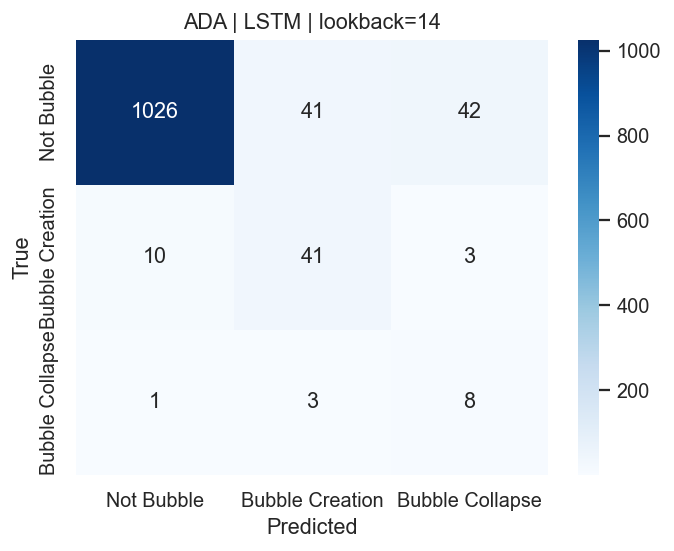

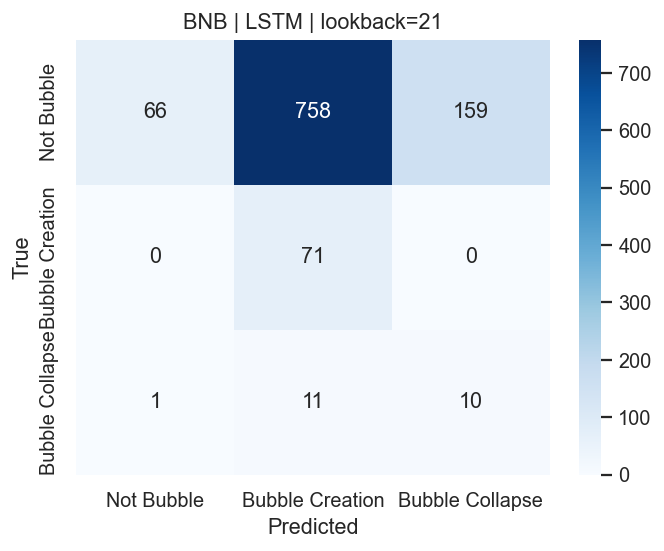

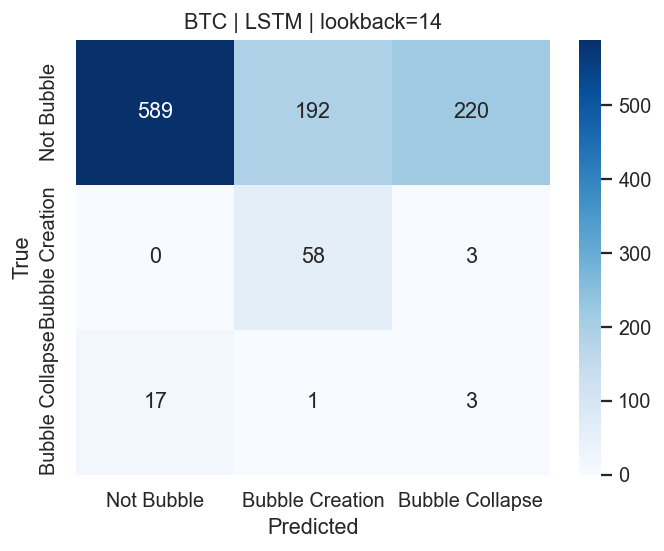

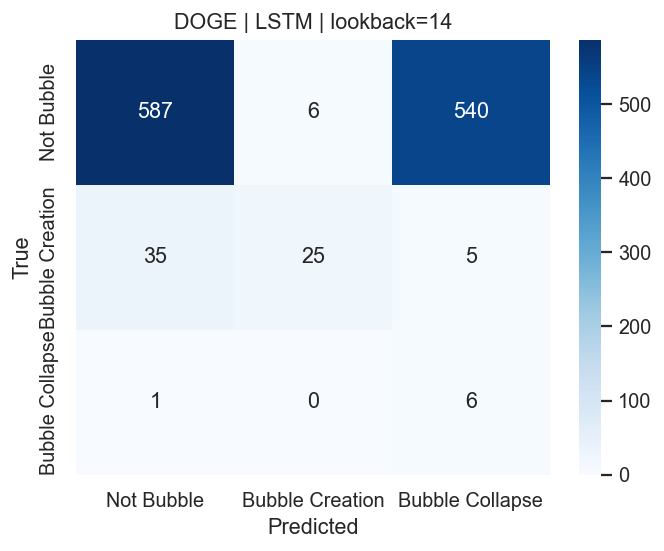

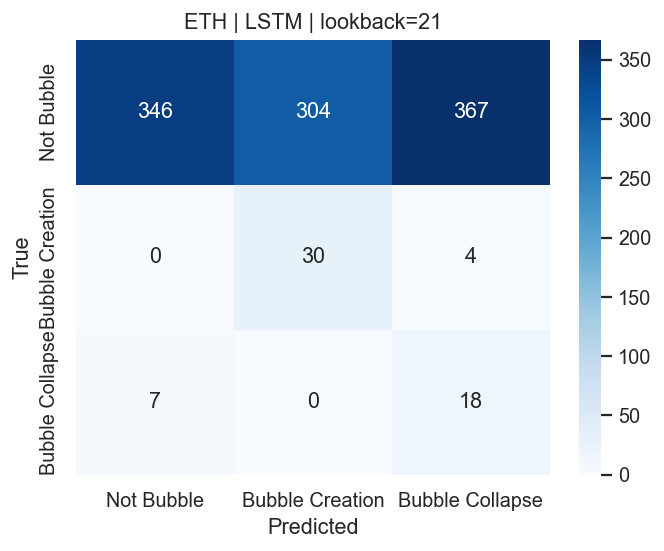

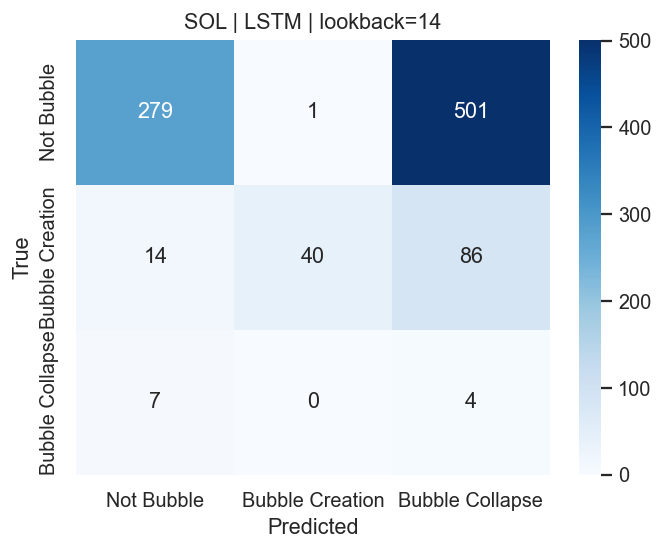

In [19]:

def plot_confusion_matrix_for_result(result):
    cm = confusion_matrix(result["y_test"], result["y_pred"], labels=LABELS)
    plt.figure(figsize=(5.4, 4.4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
    )
    plt.title(f"{result['coin']} | LSTM | lookback={result['lookback']}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

for result in all_results:
    plot_confusion_matrix_for_result(result)


## 16. Heatmaps

Visual comparison of key metrics across coins.


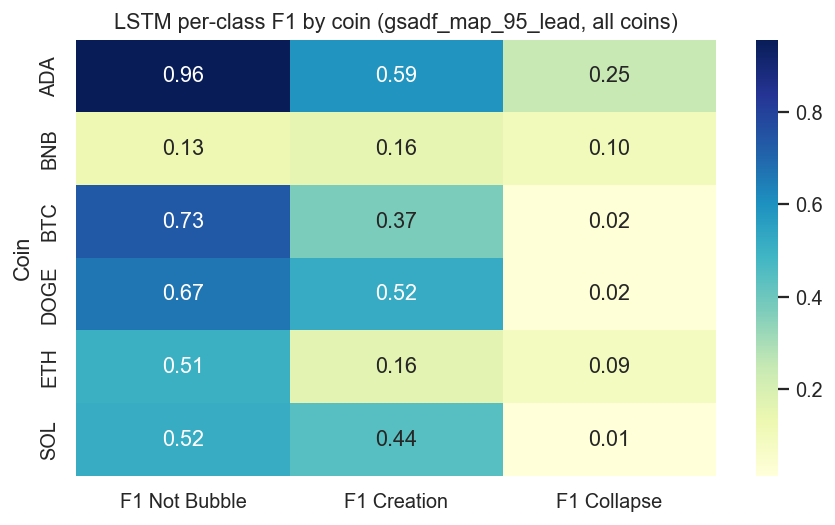

In [20]:

if not summary_df.empty:
    heatmap_df_all = summary_df.set_index("Coin")[["F1 Not Bubble", "F1 Creation", "F1 Collapse"]]
    plt.figure(figsize=(7, max(3, len(heatmap_df_all) * 0.7)))
    sns.heatmap(heatmap_df_all, annot=True, fmt=".2f", cmap="YlGnBu")
    plt.title(f"LSTM per-class F1 by coin ({TARGET_COL}, all coins)")
    plt.tight_layout()
    plt.show()


## 17. Training Curves

Plot loss and metric curves for the selected run of each coin.


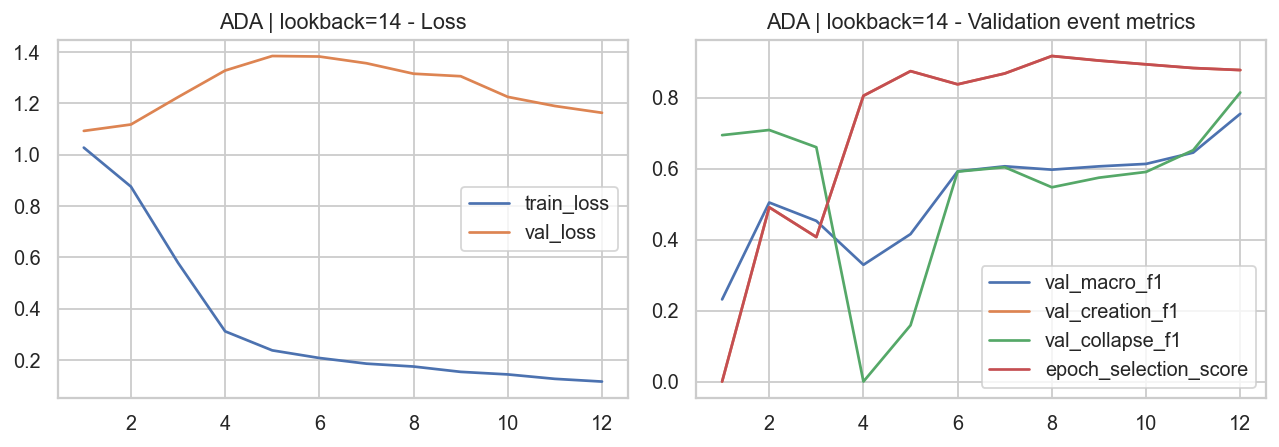

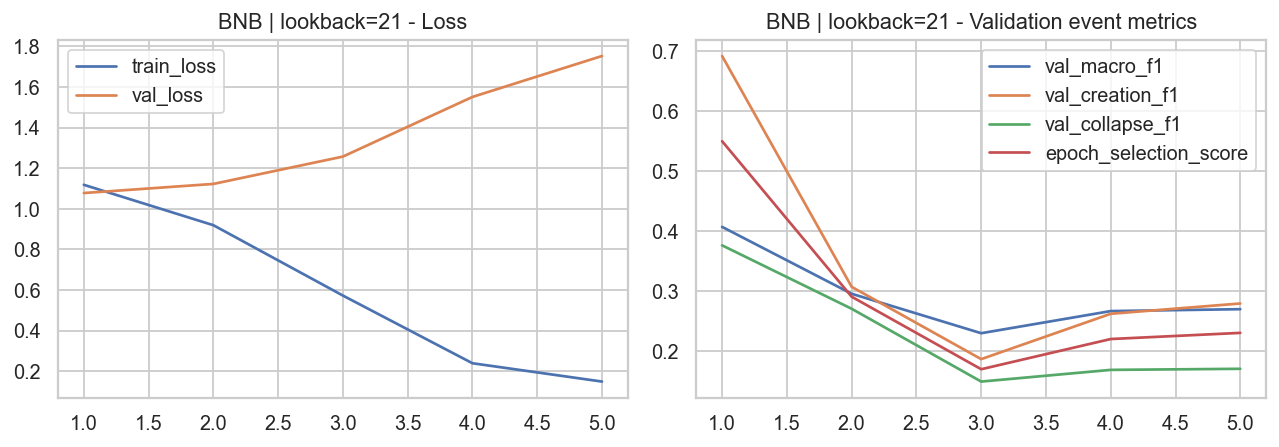

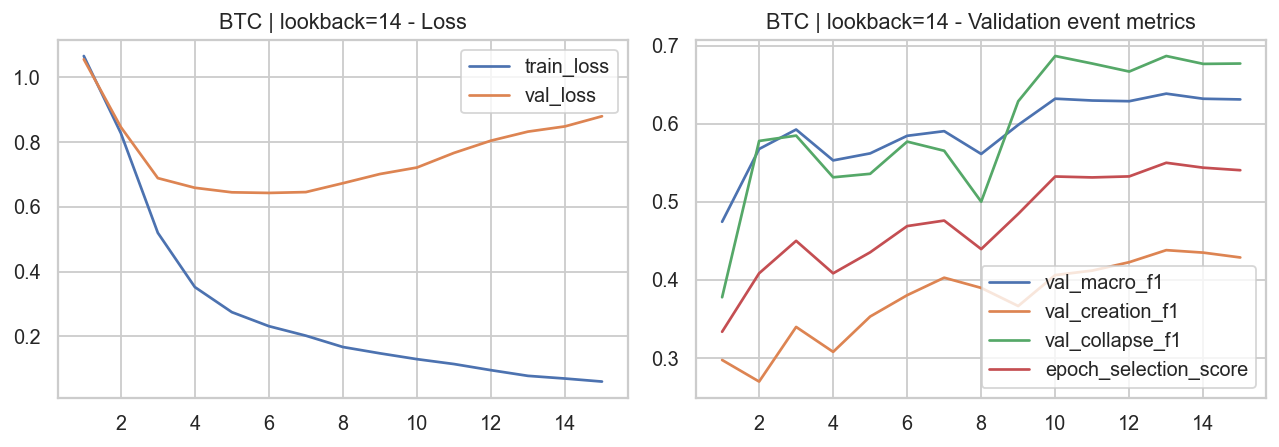

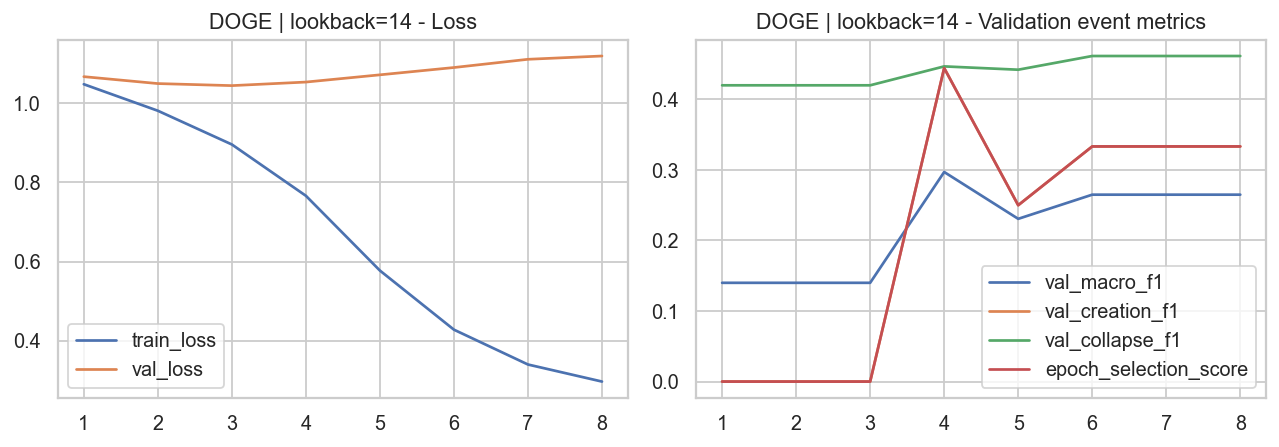

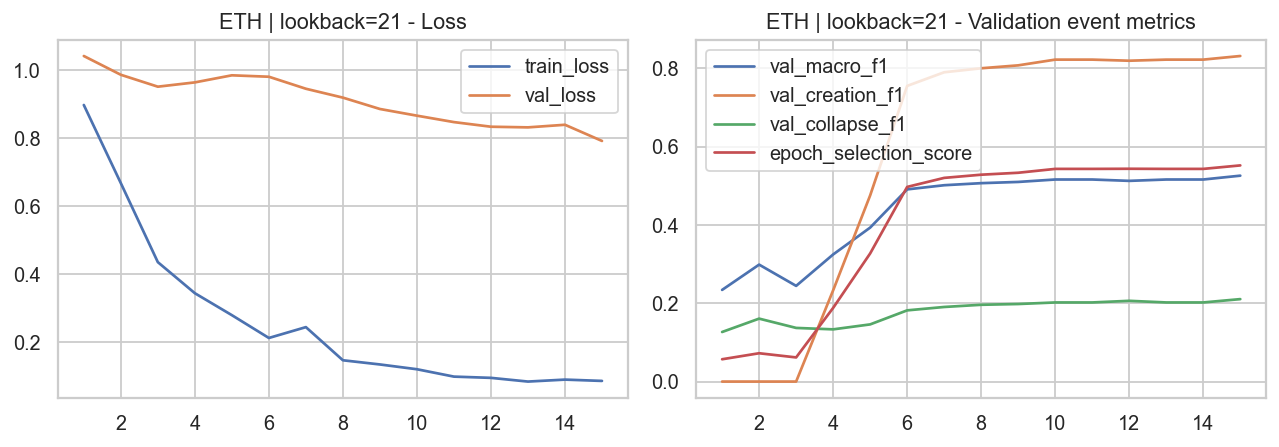

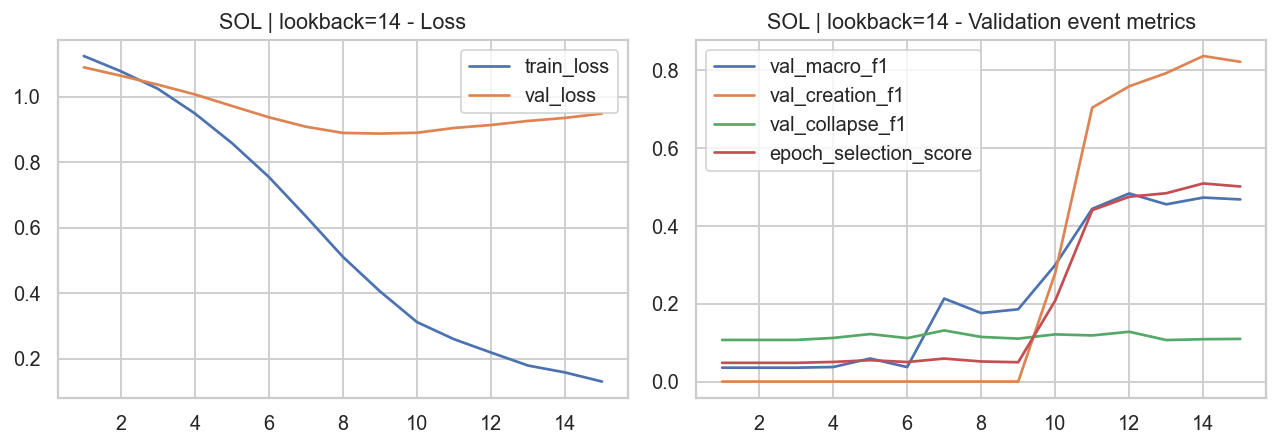

In [21]:

def plot_history(history_df, title):
    if history_df.empty:
        return
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["val_macro_f1"], label="val_macro_f1")
    axes[1].plot(history_df["epoch"], history_df["val_creation_f1"], label="val_creation_f1")
    axes[1].plot(history_df["epoch"], history_df["val_collapse_f1"], label="val_collapse_f1")
    axes[1].plot(history_df["epoch"], history_df["epoch_selection_score"], label="epoch_selection_score")
    axes[1].set_title(f"{title} - Validation event metrics")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

for result in all_results:
    plot_history(result["history"], f"{result['coin']} | lookback={result['lookback']}")


## 18. Optional Robustness Rerun (`gsadf_map_90_lead`)

Optional rerun for coins with sparse collapse labels under the main target.


In [22]:

RUN_90_ROBUSTNESS = False

if RUN_90_ROBUSTNESS:
    robustness_results = []
    for coin in SPARSE_COLLAPSE_ROBUSTNESS_COINS:
        result = run_coin_experiment(
            coin=coin,
            df=df,
            feature_cols=FEATURE_COLS,
            target_col=ROBUSTNESS_TARGET_COL,
        )
        robustness_results.append(result)

    robustness_rows = []
    for result in robustness_results:
        y_true = result["y_test"]
        y_pred = result["y_pred"]
        f1_pc = f1_score(y_true, y_pred, average=None, labels=LABELS, zero_division=0)
        robustness_rows.append({
            "Coin": result["coin"],
            "Target": result["target_col"],
            "Lookback": result["lookback"],
            "F1 Not Bubble": round(float(f1_pc[0]), 4),
            "F1 Creation": round(float(f1_pc[1]), 4),
            "F1 Collapse": round(float(f1_pc[2]), 4),
            "Test Collapse N": int(result["test_counts"].get(COLLAPSE_CLASS, 0)),
        })
    robustness_df = pd.DataFrame(robustness_rows).sort_values("Coin").reset_index(drop=True)
    display(robustness_df)
    robustness_df.to_csv(OUTPUT_DIR / f"robustness_sparse_coins_{ROBUSTNESS_TARGET_COL}.csv", index=False)
else:
    print(
        "Set RUN_90_ROBUSTNESS = True to rerun "
        f"{SPARSE_COLLAPSE_ROBUSTNESS_COINS} with {ROBUSTNESS_TARGET_COL}."
    )


Set RUN_90_ROBUSTNESS = True to rerun ['ADA', 'DOGE', 'ETH'] with gsadf_map_90_lead.


## 19. Interpretation Notes

- Use the **all-coins table** for the overall 3-class picture.
- Use the **collapse benchmark table** for fairer comparison of collapse performance.
- Interpret **ADA** and **DOGE** more cautiously for collapse prediction because of limited out-of-sample collapse events.
